#Lab02 - "Evaluating Supervised ML Classification Algorithms"
Artificial Intelligence (Spring 2026), University of St. Gallen

## Objectives:
In this coding lab, we will explore the fundamentals of evaluating supervised machine learning algorithms for image classification, focussing on the following concepts:

- Measuring classification performance:
    - Accuracy
    - Error-rate
    - Top-k accuracy

- Measuring retrieval performance:
    - Confusion matrix
    - Precision
    - Recall

- Confidence-based benchmarking:
    - ROC curves
    - Recall-Precision curves
    - Average Precision

At the end of this lab you should have a deep understanding of the aforementioned concepts.

##Introduction
Evaluating supervised learning algorithms means measuring how well a model learns the relationship between input features and target labels on unseen data. The ultimate goal is to estimate generalization performance — how well the model will perform on new data.

Since the main topic of this lab is evaluation, we are going to use pre-trained neural network models and evaluate their performance on the image classification task.

The principles of neural network training and hyperparameter tuning will be covered in subsequent modules. In this section, we regard them mainly as representative machine learning models.

## The image classification task
Image classification is a supervised machine learning task where the goal is to assign a predefined label (or class) to an entire image based on its visual content. Given an input image, a trained model learns to recognize patterns, shapes, textures or other structures in the image and decide which category it belongs to, such as “cat,” “dog,” “car,” etc.


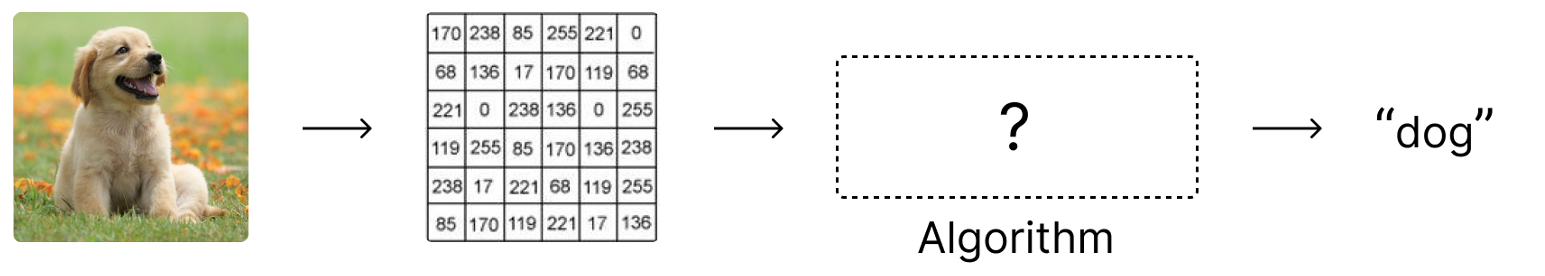

###CIFAR-10 dataset
The CIFAR-10 database (Canadian Institute For Advanced Research) is a collection of images that are commonly used to train machine learning and computer vision algorithms. The database is widely used to conduct computer vision research using machine learning and deep learning methods:

CIFAR-10 contains 60,000 color images (50,000 training images and 10,000 validation images). The size of each image is 32 by 32 pixels. The collection of images encompasses 10 different classes that represent airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks.

Additionally, CIFAR-10 has a balanced number of images per class, these are 6,000 images per class in total:
*   5,000 per class in the training set
*   1,000 per class in the test set

Further details on the dataset can be obtained via:

 [Krizhevsky, A., 2009. "Learning Multiple Layers of Features from Tiny Images"](https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf).




## Part 0: Preparatory steps

Here we will take some preparatory steps that are essential for conducting the evaluation of the machine learning algorithms:

1. Setup of the lab environment
2. Load and visualize the image dataset
3. Load pre-trained image classification models
4. Implementation of a prediction function.


### 1. Setup of the lab environment
For this coding lab we are going to use a number of python packages to make our lives easier:

In [ ]:
# Tensor manipulation & Neural networks & Datasets & Dataloaders
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Functions that automatically compute metrics necessaty for this lab.
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import average_precision_score

In [ ]:
# Enable notebook matplotlib inline plotting.
%matplotlib inline

### 2. Load and visualize the image dataset
To make predictions on the image data we first need to load them. In Pytorch, we first instantiate a dataset class - here we are using the one specifically provided for CIFAR-10 by the torchvision package. Then, we instantiate a dataloader that loads the data to the memory for processing. A dataloader takes a dataset and splits it up into batches. A batch contains a list of images and their corresponding labels.

You will notice that during the instantiation of the dataset we pass a transform callback function. This makes sure that every image is normalized accordingly, and is important because our pre-trained models have been trained with normalized images.

In [ ]:
# Normalization is required since the models are trained on normalized data.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

# Initializing the test dataset.
testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Initializing the test dataloader.
batch_size = 128
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
def show_images(images, labels, classes_names, limit=10):
    """
    Display a row of images with their class names and indices.

      Given a batch of images and their corresponding label indices, this
      function plots up to `limit` images in a single row, denormalizes them,
      and shows each image with its class name and label index above it.

      The images are assumed to be in CHW format and normalized to the range
      [-1, 1] (hence the denormalization step).

      Args:
          images (torch.Tensor): A batch of image tensors with shape
              `(batch_size, channels, height, width)`.
          labels (torch.Tensor or list[int]): Corresponding class indices for
              the images.
          classes_names (list[str]): List of class names where the index
              corresponds to the label.
          limit (int, optional): Maximum number of images to display. Defaults
              to 10.

      Returns:
          None: The function displays a plot, it does not return a value.
    """

    images = images.numpy()
    images = images[:limit]

    fig, axes = plt.subplots(1, len(images), figsize=(15,3))

    for i, ax in enumerate(axes):
        img = np.transpose(images[i], (1,2,0))  # CHW -> HWC
        img = img * 0.5 + 0.5 # de-normalization
        ax.imshow(img)
        ax.set_title(f"{classes_names[labels[i]]} ({labels[i]})")
        ax.axis("off")

    plt.show()

It is usually a good idea to visualize your data and the corresponding labels before you proceed with the rest of the code. To display some images from the test set we will use the following code. Remember, the size of each image is 32 by 32 pixels and that is why they appear pixelated.

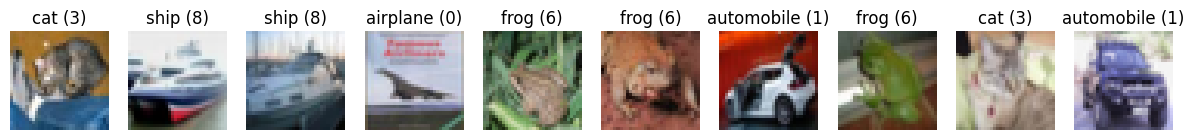

In [ ]:
# Gets a batch of images-labels from the test dataloader.
dataiter = iter(testloader)
images, labels = next(dataiter)

# The names of the CIFAR-10 classes
classes = ("airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")

show_images(images, labels, classes, limit=10)

### 3. Load pre-trained image classification models
As we already mentioned, we are using pre-trained image classification neural network models. The theory for this models is covered later in the course.

Here we will stick to the basics needed to load a pretrained neural network in Pytorch:
- a checkpoint file (contains the state of the model)
- the model's specification class (describes the architecture)

In our case, the model checkpoint files are stored in our [teaching github repo](https://github.com/HSG-AIML-Teaching/AI2026-Lab/tree/main/checkpoints). To save them locally we execute the following commands:

In [ ]:
!mkdir checkpoints
!wget -O checkpoints/model_A.pth "https://cdn.jsdelivr.net/gh/hsg-aiml-teaching/ai2026-lab@77508fe/checkpoints/model_tinycnn_epoch_5.pth"
!wget -O checkpoints/model_B.pth "https://cdn.jsdelivr.net/gh/hsg-aiml-teaching/ai2026-lab@77508fe/checkpoints/model_simplecnn_epoch_5.pth"

mkdir: cannot create directory ‘checkpoints’: File exists
--2026-03-12 14:55:14--  https://cdn.jsdelivr.net/gh/hsg-aiml-teaching/ai2026-lab@77508fe/checkpoints/model_tinycnn_epoch_5.pth
Resolving cdn.jsdelivr.net (cdn.jsdelivr.net)... 104.16.175.226, 104.16.174.226, 2606:4700::6810:aee2, ...
Connecting to cdn.jsdelivr.net (cdn.jsdelivr.net)|104.16.175.226|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/octet-stream]
Saving to: ‘checkpoints/model_A.pth’

checkpoints/model_A     [ <=>                ] 538.33K  --.-KB/s    in 0.04s   

2026-03-12 14:55:14 (12.4 MB/s) - ‘checkpoints/model_A.pth’ saved [551249]

--2026-03-12 14:55:14--  https://cdn.jsdelivr.net/gh/hsg-aiml-teaching/ai2026-lab@77508fe/checkpoints/model_simplecnn_epoch_5.pth
Resolving cdn.jsdelivr.net (cdn.jsdelivr.net)... 104.16.175.226, 104.16.174.226, 2606:4700::6810:aee2, ...
Connecting to cdn.jsdelivr.net (cdn.jsdelivr.net)|104.16.175.226|:443... connected.
HTTP request 

To load the models correctly, we need the model specification classes. The cell below provides these classes for each model. Don't worry about how they work internally — for our purposes, you can treat the models as black boxes.

In [ ]:
class TinyCNN(nn.Module):
    def __init__(self):
        super(TinyCNN, self).__init__()

        # 1st conv block
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # 2nd conv block
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # final classifier
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 32→16 spatial
        x = self.pool(F.relu(self.conv2(x)))  # 16→8 spatial

        x = x.view(-1, 32 * 8 * 8)            # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64*8*8,256),
            nn.ReLU(),
            nn.Linear(256,10)
        )

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        x = self.fc(x)
        return x

Finally, we load the models using the following code:

In [ ]:
model_A = TinyCNN()
model_B = SimpleCNN()
model_A.load_state_dict(torch.load("checkpoints/model_A.pth", weights_only=False, map_location="cpu"))
model_B.load_state_dict(torch.load("checkpoints/model_B.pth", weights_only=False, map_location="cpu"))

<All keys matched successfully>

### 4. Implementation of a prediction function
We need a function that takes a dataloader and a trained model and returns the predictions made by the model.

The illustration below shows what happens for one image of the batch returned by the dataloader. The scores per class correspond to the `outputs` of the prediction function.

Additionally, the prediction will take the `outputs` and find the index of the highest score. This way, the index of the predicted class (in the illustration is 0) is returned. The function stores these class indexes in `predictions`.

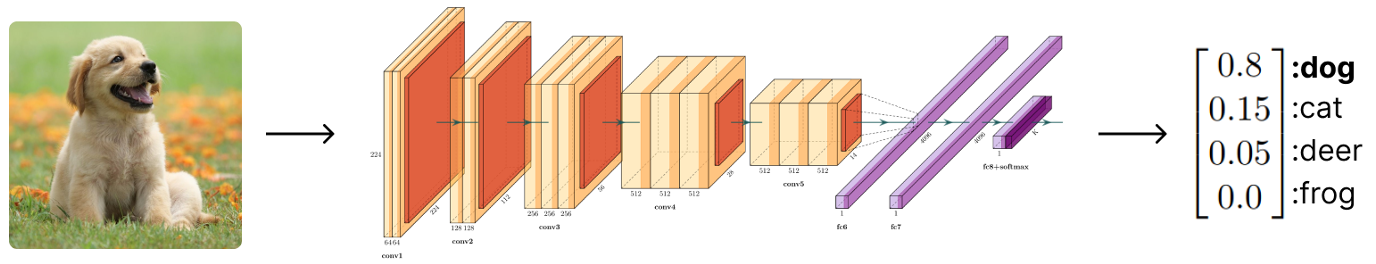

In [ ]:
def predict(model, dataloader, device="cpu"):
  """
    Generate predictions and model outputs for a dataset.

    Iterates over all batches in a dataloader with the model in evaluation
    mode, collects the predicted class indices as well as the raw model
    outputs (typically logits or scores).

    Args:
        model (torch.nn.Module): The trained PyTorch model used for inference.
        dataloader (torch.utils.data.DataLoader): DataLoader providing batches
            of images to predict on.
        device (str or torch.device, optional): Device on which to perform computation.

    Returns:
        tuple:
            numpy.ndarray: 1D array of predicted class indices for all samples.
            numpy.ndarray: 2D array of raw outputs (shape [n_samples, n_classes])
            from the model before applying any activation (e.g., softmax).
  """
  model.eval()

  all_preds = []
  all_outputs = []
  with torch.no_grad():
      for images, _ in dataloader:
          images = images.to(device)
          outputs = model(images)
          _, predicted = torch.max(outputs, 1)
          all_preds.extend(predicted.cpu().numpy())
          all_outputs.append(outputs.cpu().numpy())

  predictions = np.array(all_preds)
  outputs = np.concatenate(all_outputs, axis=0)
  return predictions, outputs

Get the predictions and outputs of the models on the test data:
- predictions: A one-dimensional vector containing the predicted class indices where each component corresponds to an image.
- outputs: A two-dimensional vector containing predicted scores where each row corresponds to an image, and each column to a class_index.

> Reminder: The test set contains 10'000 images and CIFAR-10 has 10 classes.


In [ ]:
preds_A, outs_A = predict(model_A, testloader)
preds_B, outs_B = predict(model_B, testloader)

print(preds_A.shape)
print(outs_A.shape)

(10000,)
(10000, 10)


Get the ground truth labels of the test data:

In [ ]:
labels = np.array(testset.targets)

In [ ]:
print(preds_A)
print(labels)
print(preds_A == labels)

[3 8 0 ... 5 1 7]
[3 8 8 ... 5 1 7]
[ True  True False ...  True  True  True]


## Part 1: Measuring the classification performance
1. Compute the accuracy and error rate.
2. Compute the top-k accuracy.


### 1. Compute the accuracy and error rate
In image classification, accuracy is the proportion of predictions that match the true labels in the dataset:


$$
\text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of samples}}
$$

For example, if a model classifies 900 out of 1000 images correctly, the accuracy is:

$$
\text{Accuracy} = \frac{900}{1000} = 0.9 = 90\%
$$

The error rate is computed as:

$$
\text{Error rate} = 1 - \text{Accuracy}
$$

>Hint: Using error rate instead of accuracy is mostly a matter of interpretation and analysis convenience. The two metrics contain the same information but emphasize different perspectives.

In [ ]:
accuracy_A = (preds_A == labels).mean()
error_rate_A = 1 - accuracy_A
print(f"Accuracy of model A: {accuracy_A:.3f}")
print(f"Error Rate of model A: {error_rate_A:.3f}")

print() # empty line

accuracy_B = (preds_B == labels).mean()
error_rate_B = 1 - accuracy_B
print(f"Accuracy of model B: {accuracy_B:.3f}")
print(f"Error Rate of model B: {error_rate_B:.3f}")

Accuracy of model A: 0.654
Error Rate of model A: 0.346

Accuracy of model B: 0.723
Error Rate of model B: 0.277


### 2. Compute the top-k accuracy

Top-k accuracy is a metric used in multiclass classification to evaluate whether the correct class appears among the model's k most confident predictions.

Unlike standard accuracy (Top-1), top-k accuracy allows the correct class to appear anywhere within the top k predicted classes.


When a model predicts probabilities for each class, it usually produces a
ranking of classes.

| Rank | Predicted class | Probability |
| ---- | --------------- | ----------- |
| 1    | dog             | 0.55        |
| 2    | wolf            | 0.25        |
| 3    | fox             | 0.10        |
| 4    | cat             | 0.07        |
| 5    | coyote          | 0.03        |


If the true label is "fox":

- Top-1 accuracy → incorrect (because prediction #1 is "dog")

- Top-3 accuracy → correct (because "fox" is in the top 3 predictions)

It is expected that as k increases the top-k accuracy increases as well.

> Use Case: Top-k accuracy is used instead of top-1 accuracy when the task allows multiple plausible correct predictions, or when the model is evaluated on hard-to-distinguish classes.

In [ ]:
def compute_topk_accuracy(outs, labels, k=5):
  topk = torch.topk(torch.from_numpy(outs), k=k, dim=1).indices

  correct = 0
  total = 0

  for i, label in enumerate(labels):
      if label in topk[i]:
          correct += 1
      total += 1

  return correct/total

In [ ]:
top5 = compute_topk_accuracy(outs_A, labels, k=5)
top3 = compute_topk_accuracy(outs_A, labels, k=3)
top1 = compute_topk_accuracy(outs_A, labels, k=1)

print(f"Top-5 accuracy for model A: {top5}")
print(f"Top-3 accuracy for model A: {top3}")
print(f"Top-1 accuracy for model A: {top1}")

print() # empty line

top5 = compute_topk_accuracy(outs_B, labels, k=5)
top3 = compute_topk_accuracy(outs_B, labels, k=3)
top1 = compute_topk_accuracy(outs_B, labels, k=1)

print(f"Top-5 accuracy for model B: {top5}")
print(f"Top-3 accuracy for model B: {top3}")
print(f"Top-1 accuracy for model B: {top1}")

Top-5 accuracy for model A: 0.9684
Top-3 accuracy for model A: 0.9009
Top-1 accuracy for model A: 0.6544

Top-5 accuracy for model B: 0.9778
Top-3 accuracy for model B: 0.9284
Top-1 accuracy for model B: 0.7225


## Part 2: Measuring retrieval performance
1. Compute the confusion matrix
2. Compute precision and recall

### 1. Compute the confusion matrix

A confusion matrix is a table used in Machine Learning and Statistics to evaluate how well a classification model performs. It compares the actual labels with the predicted labels made by the model.


For a binary classification problem (e.g., spam vs. not spam), it usually looks like this:

|                     | **Predicted Positive** | **Predicted Negative** |
| ------------------- | ---------------------- | ---------------------- |
| **Actual Positive** | True Positive (TP)     | False Negative (FN)    |
| **Actual Negative** | False Positive (FP)    | True Negative (TN)     |

>FP is also known as `type I` error and FN is also known as `type II` error.



How to interpret ?

- Rows → Actual (True) classes

- Columns → Predicted classes

- Cells → Number of samples predicted as that class.

The diagonal elements represent correct predictions, while off-diagonal elements represent misclassifications.
>For more information regarding confusion matrices and metrics for evaluating ML algorithms you can also take a look [here](https://en.wikipedia.org/wiki/Confusion_matrix).

In [ ]:
cm_A = confusion_matrix(labels, preds_A)
cm_B = confusion_matrix(labels, preds_B)

We will use the seaborn package to visualize the confusion matrices:

In [ ]:
def visualize_confusion_matrix(cm, classes, fmt="d", figsize=(8, 6)):
  plt.figure(figsize=figsize)

  sns.heatmap(cm, annot=True, fmt=fmt, cmap="YlGnBu", cbar=False)

  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  # plt.title("Confusion Matrix")

  # set class names as ticks
  plt.xticks(ticks=np.arange(len(classes)) + 0.5, labels=classes, rotation=45)
  plt.yticks(ticks=np.arange(len(classes)) + 0.5, labels=classes, rotation=0)
  plt.tight_layout()
  plt.show()

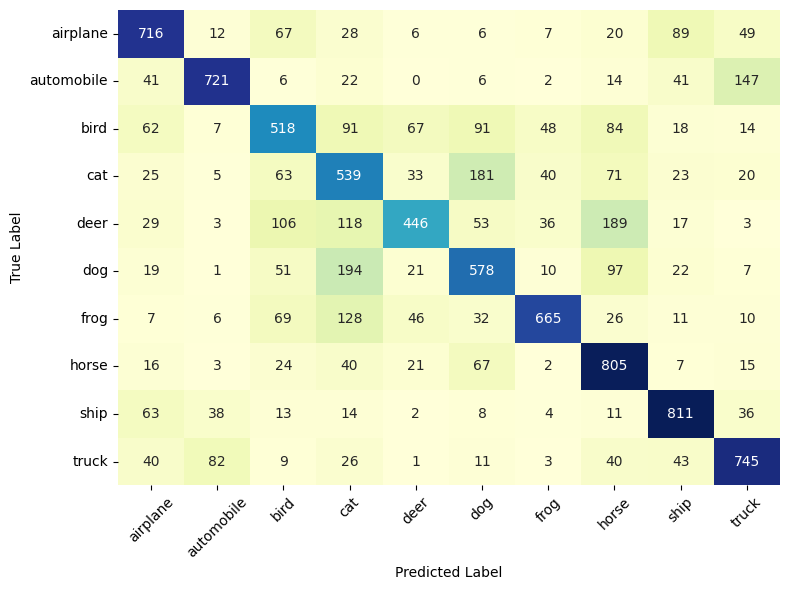

In [ ]:
visualize_confusion_matrix(cm_A, classes)

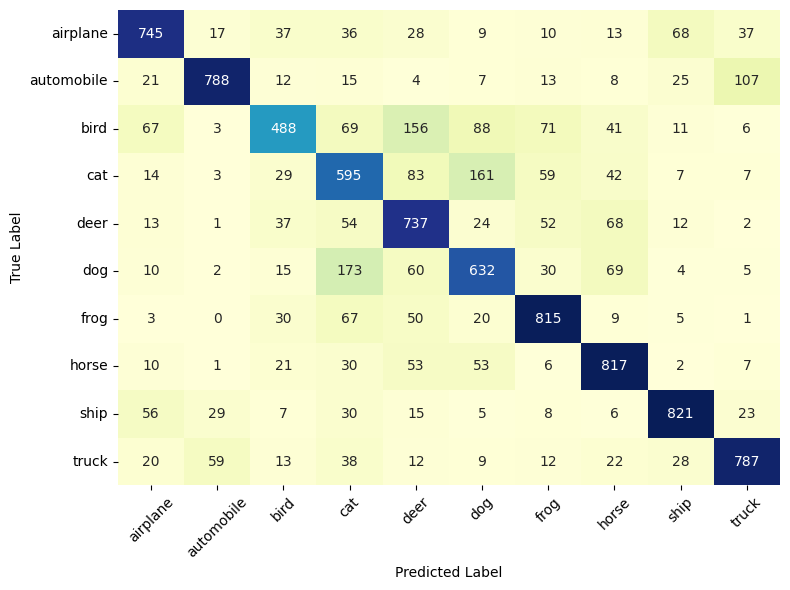

In [ ]:
visualize_confusion_matrix(cm_B, classes)

Normalized confusion matrix:

A normalized confusion matrix is a variation of a confusion matrix where the raw counts are converted into proportions or percentages instead of absolute numbers. This makes it easier to interpret model performance.


Row Normalization (most common):

Each row is divided by the total actual samples in that class.

In [ ]:
cm_norm_A = cm_A.astype('float') / cm_A.sum(axis=1)[:, np.newaxis]
cm_norm_B = cm_B.astype('float') / cm_B.sum(axis=1)[:, np.newaxis]

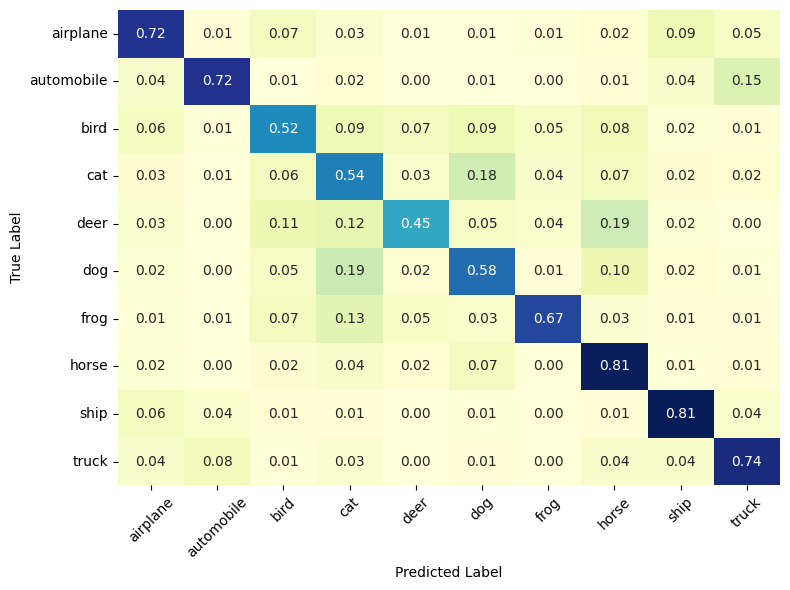

In [ ]:
visualize_confusion_matrix(cm_norm_A, classes, fmt=".2f")

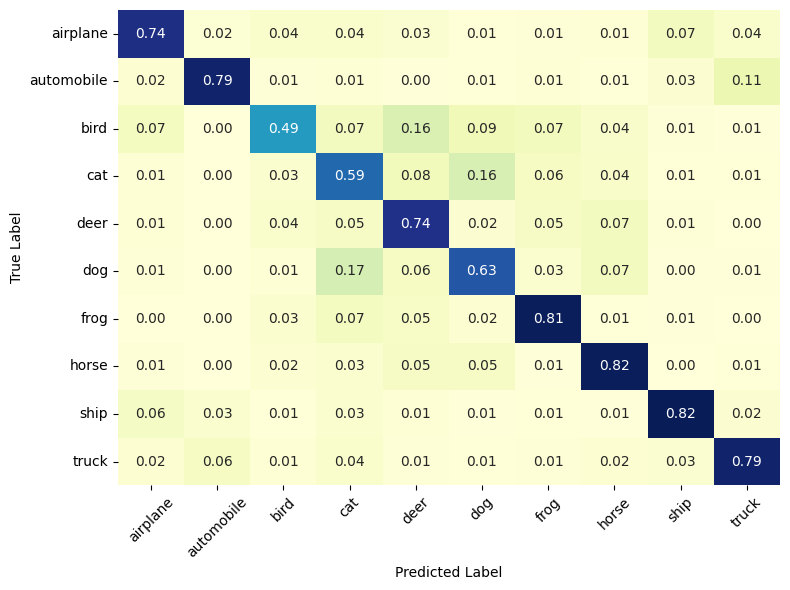

In [ ]:
visualize_confusion_matrix(cm_norm_B, classes, fmt=".2f")

### 2. Compute precision and recall

**Precision** measures how many of the predicted positives are actually correct.

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

Interpretation:

>“When the model predicts positive, how often is it right?”

Example:

A spam filter marks 100 emails as spam:

80 are actually spam (TP = 80)

20 are not spam (FP = 20)

Precision = 80 / (80 + 20) = 0.80 (80%)


**Recall** measures how many of the actual positives the model successfully finds.

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

Interpretation:

>“Out of all real positive cases, how many did the model detect?”

Example:

There are 120 spam emails total:

Model correctly finds 80 (TP = 80)

Misses 40 (FN = 40)

Recall = 80 / (80 + 40) = 0.67 (67%)

In [ ]:
def compute_precision_recall(cm, class_id=None):
  TP = np.diag(cm)
  FP = cm.sum(axis=0) - TP
  FN = cm.sum(axis=1) - TP

  precision = TP / (TP + FP)
  recall = TP / (TP + FN)

  if class_id is not None:
      precision = precision[class_id]
      recall = recall[class_id]

  print(f"Precision per class: {precision:.3f}")
  print(f"Recall per class: {recall:.3f}")

In [ ]:
compute_precision_recall(cm_A, class_id=0)

Precision per class: 0.703
Recall per class: 0.716


In [ ]:
compute_precision_recall(cm_B, class_id=0)

Precision per class: 0.777
Recall per class: 0.745


## Part 3: Confidence-based benchmarking
1. Compute the ROC curve
2. Compute the PR curve
3. Compute Average Precision

### 1. Compute the ROC curve
A ROC curve (Receiver Operating Characteristic curve) is a graphical tool used to evaluate the performance of a binary classification model in Machine Learning. It shows how well a model distinguishes between classes across different decision thresholds.

ROC curves are naturally defined for binary classification, so for multiclass classification we need strategies that convert the problem into several binary evaluations. The most common method is One-vs-Rest (OvR).

In OvR for each class:

- treat that class as positive

- treat all other classes as negative

To compute ROC curves for multiclass models, we convert the problem into multiple binary problems. That said, we one-hot encode the ground-truth labels:

In [ ]:
n_classes = 10

# one-hot encoding is needed to implement one-vs-rest.
binarized_labels = label_binarize(labels, classes=list(range(n_classes)))

print(f"1st label is: {labels[0]}")
print(f"1st label in one-hot encoding is: {binarized_labels[0]}")
print(f"The shape of one-hot encoded labels is: {binarized_labels.shape}")

1st label is: 3
1st label in one-hot encoding is: [0 0 0 1 0 0 0 0 0 0]
The shape of one-hot encoded labels is: (10000, 10)


Compute TPR and FPR at different thresholds:

The ROC curve is created by varying the classification threshold.

For each threshold t:

```
prediction = 1 if score >= t else 0
```

Then compute:
- **True Positive Rate** measures how well the model detects the positive class.


$$
\mathrm{TPR} = \frac{TP}{TP + FN}
$$

- **False Positive Rate** measures how often the model incorrectly labels negative samples as positive.

$$
\mathrm{FPR} = \frac{FP}{FP + TN}
$$

Why these matter?

When you lower the decision threshold:

- TPR increases (you catch more positives)

- FPR also increases (more false alarms)



Here's an example:

| Threshold | Predictions  | TPR | FPR |
| --------- | ------------ | --- | --- |
| ∞         | all negative | 0   | 0   |
| 0.8       | [0,0,0,1]    | 0.5 | 0   |
| 0.4       | [0,1,0,1]    | 0.5 | 0.5 |
| 0.35      | [0,1,1,1]    | 1   | 0.5 |
| 0.1       | [1,1,1,1]    | 1   | 1   |


Interpreting ROC:

| AUC     | Meaning           |
| ------- | ----------------- |
| 0.5     | random classifier |
| 0.7–0.8 | acceptable        |
| 0.8–0.9 | good              |
| >0.9    | excellent         |



In [ ]:
def compute_roc_curves(y_true, y_scores):
  """
    This function computes the Receiver Operating Characteristic (ROC) curve and the
    Area Under the Curve (AUC) for each class.

    Args:
        y_true (np.ndarray):
            Ground-truth class labels of shape (n_samples, n_classes). Each value should
            be an integer representing the class index.

        y_scores (np.ndarray):
            Predicted scores or probabilities for each class with shape
            (n_samples, n_classes). Each column corresponds to the predicted
            score for a class.

    Returns:
        Tuple[Dict[int, np.ndarray], Dict[int, np.ndarray], Dict[int, float]]:
            A tuple containing three dictionaries indexed by class label:

            - fpr: False Positive Rates for each class.
            - tpr: True Positive Rates for each class.
            - roc_auc: Area Under the ROC Curve for each class.
  """
  n_classes = y_true.shape[-1]

  fpr = {}
  tpr = {}
  roc_auc = {}

  for i in range(n_classes):
      fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_scores[:, i])
      roc_auc[i] = auc(fpr[i], tpr[i])

  return fpr, tpr, roc_auc


def plot_roc_curves(fpr, tpr, roc_auc, classes):
  plt.figure(figsize=(8,6))

  for i, class_name in enumerate(classes):
      plt.plot(
          fpr[i],
          tpr[i],
          label=f"{class_name} (AUC = {roc_auc[i]:.2f})"
      )

  # random classifier baseline
  plt.plot([0,1], [0,1], 'k--', label="Random")

  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC Curves")
  plt.legend()
  plt.grid(True)

  plt.tight_layout()
  plt.show()

A Precision–Recall (PR) curve evaluates a classifier by plotting Precision vs Recall as the decision threshold changes. It focuses specifically on how well the model finds positive examples.

Example:
| Threshold | Precision | Recall |
| --------- | --------- | ------ |
| 0.9       | 1.0       | 0.2    |
| 0.7       | 0.9       | 0.5    |
| 0.5       | 0.7       | 0.7    |
| 0.3       | 0.5       | 0.9    |

Lowering the threshold:

- predicts more positives

- increases Recall

but often decreases Precision

So the trade-off is:

- High Recall → find most positives
- High Precision → predictions are reliable

>PR curves are better than ROC curves when the dataset is imbalanced.

Example:

Fraud detection:

- 1% fraud

- 99% normal

A classifier might have a very low FPR but still produce many false alarms.

ROC may look good, but precision reveals the problem!

In [ ]:
def compute_pr_curves(y_true, y_scores):
  """
  This function calculates the Precision–Recall (PR) curve for a multiclass
  classification problem using a one-vs-rest strategy.

  Args:
      y_true (np.ndarray):
          Binarized ground-truth labels of shape (n_samples, n_classes),
          where each column represents the binary indicator for a class.

      y_scores (np.ndarray):
          Predicted scores or probabilities of shape (n_samples, n_classes),
          where each column contains the predicted score for the
          corresponding class.

  Returns:
      Tuple[Dict[int, np.ndarray], Dict[int, np.ndarray], Dict[int, float]]:
          A tuple containing three dictionaries indexed by class index:

          - precision: Precision values for different thresholds.
          - recall: Recall values for different thresholds.
          - average_precision: Average Precision (AP) score for each class.
  """

  n_classes = y_true.shape[-1]

  precision = {}
  recall = {}
  average_precision = {}

  for i in range(n_classes):
      precision[i], recall[i], _ = precision_recall_curve(
          y_true[:, i], y_scores[:, i]
      )
      average_precision[i] = average_precision_score(
          y_true[:, i], y_scores[:, i]
      )

  return precision, recall, average_precision


# Plotting function:
def plot_pr_curves(precision, recall, ap, classes):
  plt.figure(figsize=(8,6))

  for i, class_name in enumerate(classes):
      plt.plot(
          recall[i],
          precision[i],
          label=f"{class_name} (AP = {ap[i]:.2f})"
      )

  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title("Precision-Recall Curves")
  plt.legend()
  plt.grid(True)

  plt.tight_layout()
  plt.show()

Below we provide extra code for plotting ROC and PR curves side-by-side.

In [ ]:
def plot_roc_pr(fpr, tpr, roc_auc, precision, recall, ap, classes):
    fig, axes = plt.subplots(1,2, figsize=(14,5))

    # ROC
    for i, name in enumerate(classes):
        axes[0].plot(fpr[i], tpr[i], label=f"{name} ({roc_auc[i]:.2f})")
    axes[0].plot([0,1],[0,1],'k--')
    axes[0].set_title("ROC Curves")
    axes[0].set_xlabel("FPR")
    axes[0].set_ylabel("TPR")
    axes[0].legend()

    # PR
    for i, name in enumerate(classes):
        axes[1].plot(recall[i], precision[i], label=f"{name} ({ap[i]:.2f})")
    axes[1].set_title("Precision-Recall Curves")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

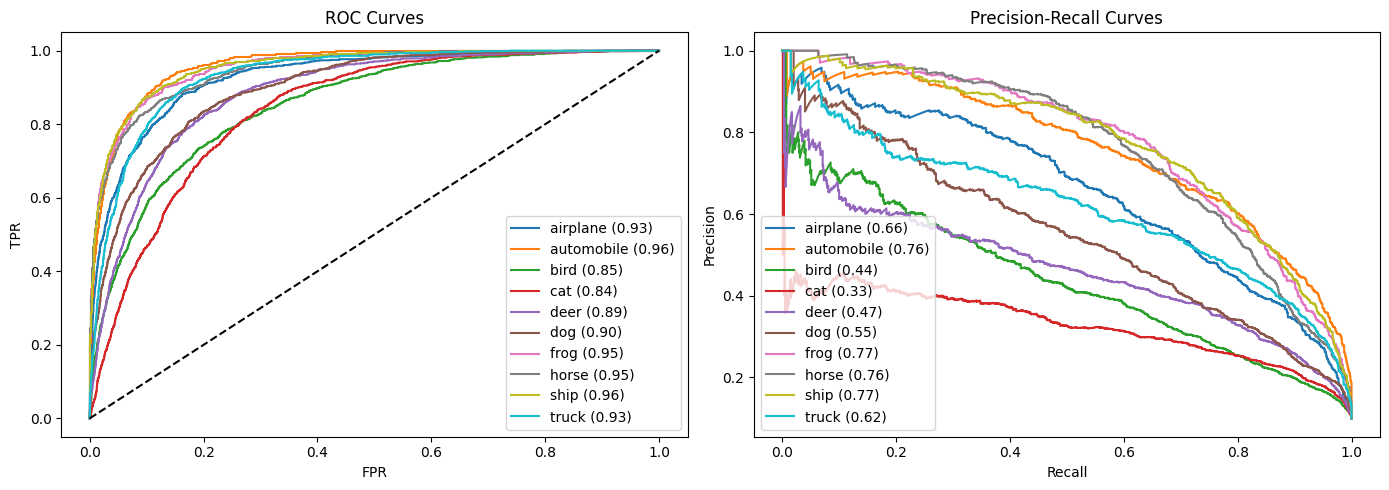

In [ ]:
fpr, tpr, roc_auc = compute_roc_curves(binarized_labels, outs_A)
precision, recall, ap = compute_pr_curves(binarized_labels, outs_A)
# plot_roc_curves(fpr, tpr, roc_auc, classes)
# plot_pr_curves(precision, recall, ap, classes)
plot_roc_pr(fpr, tpr, roc_auc, precision, recall, ap, classes)

Average Precision (AP) is a single-number metric that summarizes the Precision–Recall (PR) curve. In simple terms, it measures how good a model is at achieving high precision and high recall across all classification thresholds.

A classifier produces scores (probabilities per class). By changing the decision threshold, you obtain different:
- Precision values
- Recall values

Plotting these gives the Precision-Recall curve.

>Average Precision is the area under the Precision-Recall curve.

So AP summarizes the entire curve into one value between 0 and 1.

- 1.0 → perfect model

- 0 → very poor model

In [ ]:
def compute_average_precision(y_true, y_scores):

  n_classes = y_true.shape[-1]

  ap = {}

  for i in range(n_classes):
      ap[i] = average_precision_score(
          y_true[:, i],
          y_scores[:, i]
      )

  return ap

In [ ]:
ap = compute_average_precision(binarized_labels, outs_A)
for i in range(n_classes):
    print(f"Class {i} AP: {ap[i]:.2f}")

Class 0 AP: 0.66
Class 1 AP: 0.76
Class 2 AP: 0.44
Class 3 AP: 0.33
Class 4 AP: 0.47
Class 5 AP: 0.55
Class 6 AP: 0.77
Class 7 AP: 0.76
Class 8 AP: 0.77
Class 9 AP: 0.62


In [ ]:
map = np.mean([i for i in ap.values()])
print(f"Mean Average Precision (mAP): {map:.2f}")

Mean Average Precision (mAP): 0.61
